In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from IPython.display import display

# EDA de entregas — Parte 1: Carga y vista general
Este cuaderno realiza un análisis exploratorio por partes sobre `cleaned_data.csv`.

Estructura:
1) Carga e inspección inicial
2) Limpieza y transformaciones
3) Estadísticas y gráficos univariados
4) Series temporales con marcadores
5) Análisis por transportador y zonas
6) Resumen y siguientes pasos

In [2]:
# Leer CSV (archivo en la misma carpeta) y convertir columnas de fecha
df = pd.read_csv('cleaned_data.csv', sep=',', encoding='utf-8')
df.head()

,Campaña,Pedido,Zona,Dirección entrega,Telefono,Barrio,Ciudad,Dias entregado,Fecha recibo LD,Fecha reparto,Fecha entrega,Transportador,Estado
0,202407,37076500,V02,KR 61 18 16 APTO 486 TO V CONJ CANAVERALES 3- ...,0-3165249159,SAMANES DE GUADALUPE,CALI (VALLE),4,NaN,2024-04-22 10:27:08,2024-04-22 12:45:38,TZY274,A TIEMPO
1,202407,37087842,601,KR 47A 48 39- TEL 0-3143423923,0-3143423923,CORDOBA,CALI (VALLE),4,2024-04-27 19:07:31,2024-04-29 10:43:16,2024-04-29 22:08:43,CBZ922,A TIEMPO
2,202407,37093297,580,CR 1H NORTE 77-10 SEGUNDO PISO- TEL 0-3154678944,0-3154678944,COMFENALCO,CALI (VALLE),4,2024-04-27 19:04:43,2024-04-28 10:24:04,2024-04-28 16:40:32,TZY274,A TIEMPO
3,202407,37098642,594,CALLETERSERA SN124- TEL 0-3016931064,0-3016931064,PROVIVIENDA,DAGUA (VALLE),5,2024-04-28 20:40:40,2024-04-29 11:18:40,2024-04-30 12:00:25,TZN919,A TIEMPO
4,202407,37105003,603,CL 18 A 9 A 11 PISO NO 1- TEL 0-3136142043,0-3136142043,CARLOS GUZMAN,PUERTO TEJADA (CAUCA),5,2024-05-04 09:36:18,2024-05-04 13:10:03,2024-05-05 23:00:44,CEN356,A TIEMPO


In [3]:
#Cambiar a numericos
df['Fecha reparto'] = pd.to_datetime(df['Fecha reparto'], errors='coerce')
df['Fecha entrega'] = pd.to_datetime(df['Fecha entrega'], errors='coerce')
df['Dias entregado'] = pd.to_numeric(df['Dias entregado'], errors='coerce')
df['Fecha recibo LD'] = pd.to_datetime(df['Fecha recibo LD'], errors='coerce')

In [4]:
# Inspección rápida: tipos, nulos y conteos básicos
df.info()

# Conteo de nulos por columna (en porcentaje)
(df.isnull().mean() * 100).sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 55275 entries, 0 to 55274
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Campaña            55275 non-null  int64         
 1   Pedido             55275 non-null  int64         
 2   Zona               55275 non-null  str           
 3   Dirección entrega  55273 non-null  str           
 4   Telefono           55273 non-null  str           
 5   Barrio             55275 non-null  str           
 6   Ciudad             55275 non-null  str           
 7   Dias entregado     55275 non-null  int64         
 8   Fecha recibo LD    50971 non-null  datetime64[us]
 9   Fecha reparto      55148 non-null  datetime64[us]
 10  Fecha entrega      55016 non-null  datetime64[us]
 11  Transportador      55148 non-null  str           
 12  Estado             54992 non-null  str           
dtypes: datetime64[us](3), int64(3), str(7)
memory usage: 5.5 MB


Fecha recibo LD      7.786522
Estado               0.511986
Fecha entrega        0.468566
Fecha reparto        0.229760
Transportador        0.229760
Telefono             0.003618
Dirección entrega    0.003618
Campaña              0.000000
Zona                 0.000000
Pedido               0.000000
Dias entregado       0.000000
Barrio               0.000000
Ciudad               0.000000
dtype: float64

## Parte 2: Estadísticas descriptivas y gráficos univariados
Graficaremos estado de entrega, distribución de `Dias entregado` y de los retrasos calculados.

Estado
A TIEMPO    70.67
TARDE       29.33
Name: proportion, dtype: float64

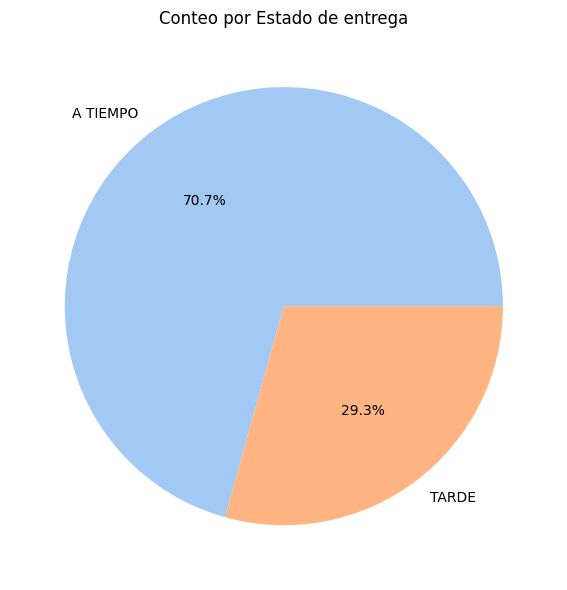

In [5]:
# Conteo por estado (A TIEMPO / TARDE u otros)
plt.figure(figsize=(6,6))
estado_counts = df['Estado'].value_counts()
colors = sns.color_palette('pastel', len(estado_counts))
plt.pie(estado_counts.values, labels=estado_counts.index, autopct='%1.1f%%', colors=colors)
plt.title('Conteo por Estado de entrega')
plt.tight_layout()

# Mostrar porcentajes por estado
display((df['Estado'].value_counts(normalize=True)*100).round(2))

## Parte 4: Series temporales y marcadores
Contar entregas por día y agregar marcadores útiles (fecha mediana y picos).

Fecha entrega
2025-09-15    751
2025-07-16    672
2024-09-17    583
dtype: int64

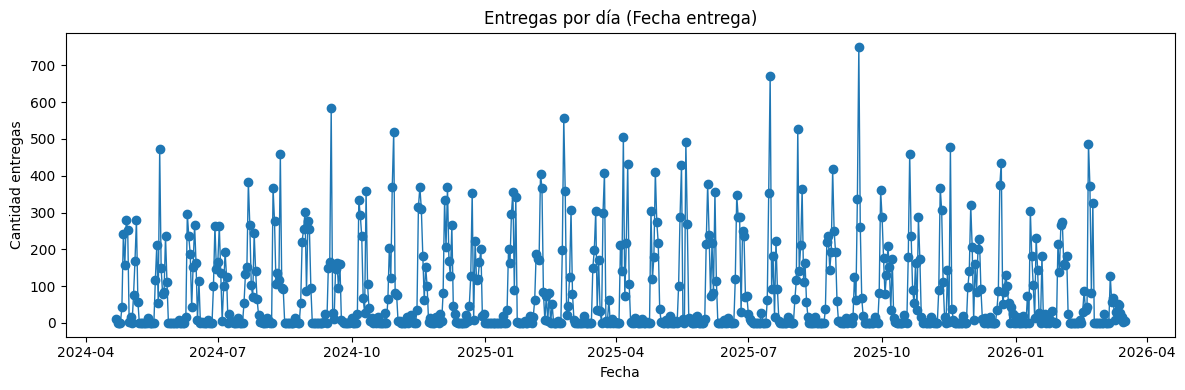

In [6]:
# Series temporales: entregas por día según 'Fecha entrega'
ts = df.dropna(subset=['Fecha entrega']).copy()
ts['Fecha entrega'] = pd.to_datetime(ts['Fecha entrega'])
ts = ts.set_index('Fecha entrega').resample('D').size()
plt.figure(figsize=(12,4))
plt.plot(ts.index, ts.values, marker='o', lw=1)
plt.title('Entregas por día (Fecha entrega)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad entregas')

plt.tight_layout()

# Mostrar los 3 días con mayor número de entregas
top3 = ts.sort_values(ascending=False).head(3)
display(top3)

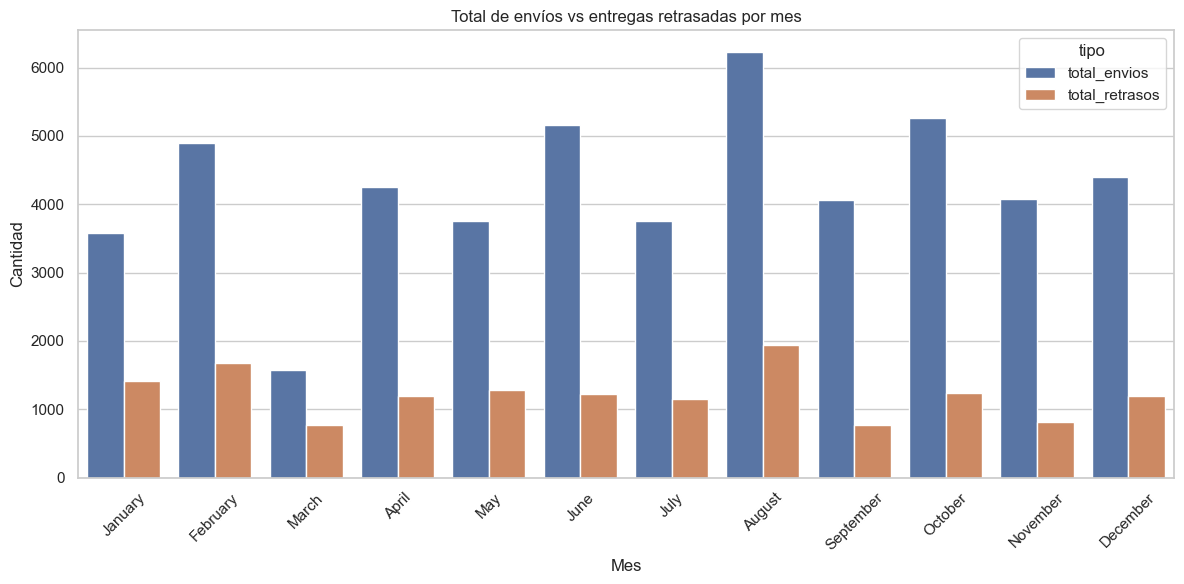

In [ ]:
df['is_delayed'] = df['Estado'].astype(str).str.upper().str.contains('TARDE', na=False)
df['mes'] = df['Fecha recibo LD'].dt.month
df['nombre_mes'] = df['Fecha recibo LD'].dt.month_name()

resumen_mes = (
    df.groupby(['mes', 'nombre_mes'])['is_delayed']
    .agg(total_retrasos='sum', total_envios='count')
    .assign(porcentaje_retraso=lambda x: x['total_retrasos'] / x['total_envios'])
    .reset_index()
    .sort_values('mes')
)

resumen_melt = resumen_mes.melt(
    id_vars='nombre_mes',
    value_vars=['total_envios', 'total_retrasos'],
    var_name='tipo',
    value_name='cantidad'
)

sns.set(style="whitegrid")

plt.figure(figsize=(12,6))
sns.barplot(
    data=resumen_melt,
    x='nombre_mes',
    y='cantidad',
    hue='tipo'
)

plt.title('Total de envíos vs entregas retrasadas por mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Parte 5: Análisis por Transportador y Zonas
Explorar transportadores principales y comportamiento de retrasos por estado/transportador.

In [ ]:
# Top 10 transportadores por número de registros
plt.figure(figsize=(8,5))
top_trans = df['Transportador'].value_counts().nlargest(10)
sns.barplot(x=top_trans.values, y=top_trans.index, palette='viridis')
plt.title('Top 10 Transportadores (número de entregas)')
plt.xlabel('Cantidad')
plt.ylabel('Transportador')
plt.tight_layout()
display(top_trans)

### Transportadores con mayor retraso promedio
A continuación calculamos el retraso promedio (en días) por `Transportador`, mostramos los top y graficamos tanto el promedio como la distribución de retrasos para esos transportadores.

In [ ]:
# Estadísticas de retraso por transportador usando la columna 'Estado' (TARDE = retraso)
# Definir indicador binario de retraso
df2 = df.copy()
df2['is_delayed'] = df2['Estado'].astype(str).str.upper().str.contains('TARDE')
# Agregar estadísticas por transportador
trans_stats = df2.groupby('Transportador').agg(
    count=('Pedido','size'),
    delayed_count=('is_delayed','sum'),
    delay_rate=('is_delayed','mean'),
).reset_index()
# Filtrar transportadores con número mínimo de registros para evitar ruido
min_count = 10
top_delay = trans_stats[trans_stats['count'] >= min_count].sort_values('delay_rate', ascending=False).head(10)
display(top_delay[['Transportador','count','delayed_count','delay_rate']])

# Gráfico: proporción de entregas retrasadas — Top transportadores
plt.figure(figsize=(8,6))
sns.barplot(x='delay_rate', y='Transportador', data=top_delay, palette='rocket')
plt.xlabel('Proporción de entregas retrasadas')
plt.title(f'Top transportadores por proporción de entregas retrasadas')
# Anotar valores en porcentaje
for i, v in enumerate(top_delay['delay_rate']):
    plt.text(v, i, f'{v:.2%}', va='center')
plt.tight_layout()

In [ ]:
# Top 10 Zonas por número de entregas
plt.figure(figsize=(8,5))
top_zonas = df['Zona'].value_counts().nlargest(10)
sns.barplot(x=top_zonas.values, y=top_zonas.index, palette='viridis')
plt.title('Top 10 Zonas (número de entregas)')
plt.xlabel('Cantidad')
plt.ylabel('Zona')
plt.tight_layout()
display(top_zonas)

In [ ]:
# Retrasos por Ciudad
city_stats = df.groupby('Ciudad').agg(
    count=('Pedido','size'),
    delayed_count=('is_delayed','sum'),
    delay_rate=('is_delayed','mean')
).reset_index()

min_count_city = 10
top_city = city_stats[city_stats['count'] >= min_count_city].sort_values('delay_rate', ascending=False).head(15)
display(top_city[['Ciudad','count','delayed_count','delay_rate']])

plt.figure(figsize=(8,6))
sns.barplot(x='delay_rate', y='Ciudad', data=top_city, palette='magma')
plt.xlabel('Proporción de entregas retrasadas')
plt.title(f'Top ciudades por proporción de entregas retrasadas')
for i, v in enumerate(top_city['delay_rate']):
    plt.text(v, i, f'{v:.2%}', va='center')
plt.tight_layout()

In [ ]:
# Retrasos por Ciudad
city_stats = df.groupby('Zona').agg(
    count=('Pedido','size'),
    delayed_count=('is_delayed','sum'),
    delay_rate=('is_delayed','mean')
).reset_index()

min_count_city = 10
top_city = city_stats[city_stats['count'] >= min_count_city].sort_values('delay_rate', ascending=False).head(15)
display(top_city[['Zona','count','delayed_count','delay_rate']])

plt.figure(figsize=(8,6))
sns.barplot(x='delay_rate', y='Zona', data=top_city, palette='magma')
plt.xlabel('Proporción de entregas retrasadas')
plt.title(f'Top zonas por proporción de entregas retrasadas')
for i, v in enumerate(top_city['delay_rate']):
    plt.text(v, i, f'{v:.2%}', va='center')
plt.tight_layout()